# AI Customer Support Ticket Classifier

This project builds a text classification model to automatically route customer support tickets to the appropriate banking intent.

Using the BANKING77 dataset, we will perform text EDA, compare a keyword-based baseline with a TF-IDF + Logistic Regression model, evaluate its performance, and analyze its classification errors.

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("default")

PRIMARY_COLOR = "forestgreen"
SECONDARY_COLOR = "mediumseagreen"
ACCENT_COLOR = "darkgreen"

In [68]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

# 1. Data Understanding

In this section, we examine the basic structure and characteristics of the training and test datasets, including their size, columns, data types, missing values, duplicates, and label distribution.

In [69]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (10003, 2)
Test shape: (3080, 2)


In [70]:
train.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [71]:
train.columns

Index(['text', 'category'], dtype='str')

In [72]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      10003 non-null  str  
 1   category  10003 non-null  str  
dtypes: str(2)
memory usage: 943.8 KB


In [73]:
print("Missing values in train:")
print(train.isnull().sum())

print("\nMissing values in test:")
print(test.isnull().sum())

Missing values in train:
text        0
category    0
dtype: int64

Missing values in test:
text        0
category    0
dtype: int64


In [74]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [75]:
train["category"].nunique()

77

In [76]:
train["category"].unique()

<ArrowStringArray>
[                                    'card_arrival',
                                     'card_linking',
                                    'exchange_rate',
                 'card_payment_wrong_exchange_rate',
                        'extra_charge_on_statement',
                          'pending_cash_withdrawal',
                            'fiat_currency_support',
                           'card_delivery_estimate',
                                 'automatic_top_up',
                                 'card_not_working',
                                 'exchange_via_app',
                              'lost_or_stolen_card',
                                        'age_limit',
                                      'pin_blocked',
                          'contactless_not_working',
                   'top_up_by_bank_transfer_charge',
                                   'pending_top_up',
                                  'cancel_transfer',
                           

In [77]:
train["category"].value_counts()

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

### Observations

- The training set contains 10,003 samples, while the test set contains 3,080 samples.
- Both datasets contain two columns: `text` and `category`.
- The `text` column contains customer queries, while `category` represents the corresponding banking intent.
- The training data contains 77 different intent categories.
- No missing values or duplicate rows were found in the initial inspection.

# 2. Select 6–8 Intents

BANKING77 contains 77 different banking intents. For this project, we select a smaller subset of intents to build and evaluate the ticket classification model.

The selected intents should have sufficient examples and represent meaningful customer support categories.

In [78]:
train["category"].unique()

<ArrowStringArray>
[                                    'card_arrival',
                                     'card_linking',
                                    'exchange_rate',
                 'card_payment_wrong_exchange_rate',
                        'extra_charge_on_statement',
                          'pending_cash_withdrawal',
                            'fiat_currency_support',
                           'card_delivery_estimate',
                                 'automatic_top_up',
                                 'card_not_working',
                                 'exchange_via_app',
                              'lost_or_stolen_card',
                                        'age_limit',
                                      'pin_blocked',
                          'contactless_not_working',
                   'top_up_by_bank_transfer_charge',
                                   'pending_top_up',
                                  'cancel_transfer',
                           

In [79]:
selected_intents = [
    "card_arrival",
    "card_not_working",
    "cash_withdrawal_not_recognised",
    "declined_card_payment",
    "lost_or_stolen_card",
    "transaction_charged_twice",
    "transfer_not_received_by_recipient",
    "cash_withdrawal_charge"
]

In [80]:
selected_data = train[train["category"].isin(selected_intents)]

In [81]:
selected_data["category"].value_counts()

category
cash_withdrawal_charge                177
transaction_charged_twice             175
transfer_not_received_by_recipient    171
cash_withdrawal_not_recognised        160
card_arrival                          153
declined_card_payment                 153
card_not_working                      112
lost_or_stolen_card                    82
Name: count, dtype: int64

## Intent Selection

The BANKING77 dataset contains 77 different banking intents. Since the project focuses on building a classification model for a smaller set of categories, we selected eight intents from the available categories.

The selected intents cover different types of customer support issues, including card-related problems, cash withdrawal issues, payment problems, and transfer-related issues. This provides a diverse and meaningful set of categories for the classification task.

The selected intents are:

- `card_arrival`
- `card_not_working`
- `cash_withdrawal_not_recognised`
- `declined_card_payment`
- `lost_or_stolen_card`
- `transaction_charged_twice`
- `transfer_not_received_by_recipient`
- `cash_withdrawal_charge`

To verify the selected categories, we first stored their names in a list. Then, `isin()` was used to identify the training samples belonging to these categories. These samples were stored in a new DataFrame called `selected_data`.

Finally, `value_counts()` was used to count the number of samples in each selected category. The results show that the selected intents contain between 82 and 177 training samples, providing enough examples for further analysis and classification.

### Selected Intent Distribution

The distribution of the selected intents is visualized to compare the number of training samples available for each category.
This provides an initial view of the class balance before moving to text-specific exploratory analysis.

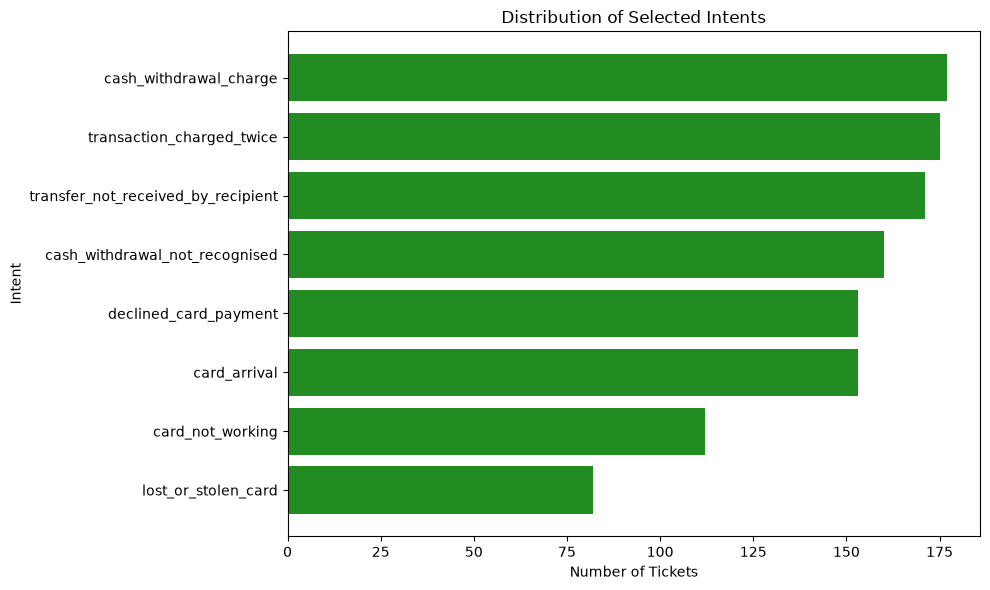

In [82]:
category_counts = selected_data["category"].value_counts().sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    category_counts.index,
    category_counts.values,
    color=PRIMARY_COLOR
)

plt.title("Distribution of Selected Intents")
plt.xlabel("Number of Tickets")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

### Observation

The selected intents are not equally represented in the training data.

`cash_withdrawal_charge` has the largest number of training samples, followed by `transaction_charged_twice` and `transfer_not_received_by_recipient`. In contrast, `lost_or_stolen_card` has the fewest training samples among the selected intents.

Although the training distribution is not perfectly balanced, the differences are moderate enough to provide a useful dataset for the selected classification task. The test set is balanced, with 40 samples per intent.

# 3. Text EDA

In this section, we explore the textual characteristics of the selected customer support tickets.

The analysis focuses on message length, word count, and differences in text structure across intents. The goal is to understand whether these characteristics provide useful information for the classification task.

## 3.1 Character Length

The character length of each ticket is calculated to examine how long customer messages are and whether message length varies across intents.

In [83]:
selected_data["char_length"] = selected_data["text"].str.len()

selected_data[["text", "char_length"]]

,text,char_length
0,I am still waiting on my card?,30
1,What can I do if my card still hasn't arrived ...,60
2,I have been waiting over a week. Is the card s...,58
3,Can I track my card while it is in the process...,59
4,"How do I know if I will get my card, or if it ...",54
...,...,...
9510,I used my card to get cash then I was charged ...,87
9511,I noticed a different charge while I was takin...,61
9512,Why was I charged a fee for withdrawing money?,46
9513,Do cash withdrawals cost anything?,34


## 3.2 Word Count

In addition to character length, the number of words in each ticket is calculated to provide another measure of message length.

In [84]:
selected_data["word_count"] = selected_data["text"].str.split().str.len()

selected_data[["text", "word_count"]]

,text,word_count
0,I am still waiting on my card?,7
1,What can I do if my card still hasn't arrived ...,13
2,I have been waiting over a week. Is the card s...,12
3,Can I track my card while it is in the process...,13
4,"How do I know if I will get my card, or if it ...",15
...,...,...
9510,I used my card to get cash then I was charged ...,19
9511,I noticed a different charge while I was takin...,12
9512,Why was I charged a fee for withdrawing money?,9
9513,Do cash withdrawals cost anything?,5


## 3.3 Length Statistics

Basic descriptive statistics are used to examine the distribution of character length and word count in the selected dataset.

In [85]:
selected_data[["char_length", "word_count"]].describe()

,char_length,word_count
count,1183.000000,1183.000000
mean,68.860524,13.726965
std,51.356720,9.861254
min,17.000000,3.000000
25%,39.000000,8.000000
50%,50.000000,10.000000
75%,73.000000,15.000000
max,339.000000,66.000000


## 3.4 Text Length by Intent

To determine whether message length differs across intents, the character length and word count are grouped by intent.

Comparing these distributions helps us identify whether some types of customer requests tend to contain longer or shorter messages.

In [86]:
selected_data.groupby("category")[["char_length", "word_count"]].mean().sort_values(
    "word_count", ascending=False
)

,char_length,word_count
category,,
transfer_not_received_by_recipient,91.567251,17.549708
transaction_charged_twice,84.125714,15.988571
cash_withdrawal_not_recognised,76.937500,15.437500
cash_withdrawal_charge,70.830508,14.152542
declined_card_payment,62.366013,12.320261
lost_or_stolen_card,49.219512,10.743902
card_arrival,47.398693,10.431373
card_not_working,48.258929,9.848214


## Text Length Comparison by Intent

To compare message length across the selected intents, we calculate the median word count and median character length for each category.

A horizontal bar chart is used because the intent names are relatively long. The median is used instead of the mean because it is less affected by unusually long or short messages.

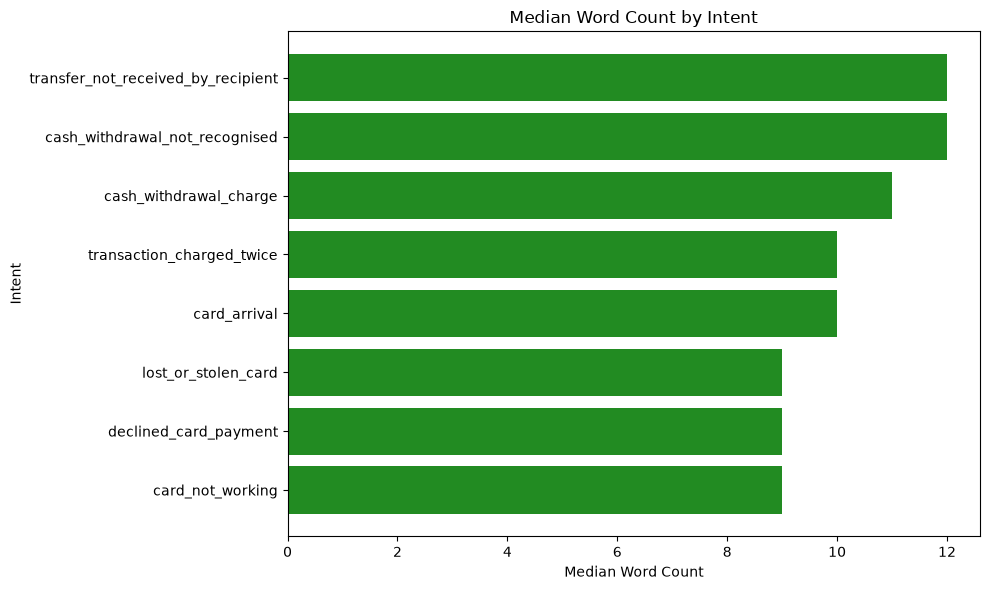

In [87]:
word_length_by_intent = (
    selected_data
    .groupby("category")["word_count"]
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    word_length_by_intent.index,
    word_length_by_intent.values,
    color=PRIMARY_COLOR
)

plt.title("Median Word Count by Intent")
plt.xlabel("Median Word Count")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

### Observation

The median word count varies across the selected intents, ranging from approximately 9 to 12 words.

`transfer_not_received_by_recipient` and `cash_withdrawal_not_recognised` have the longest median messages, while `card_not_working`, `declined_card_payment`, and `lost_or_stolen_card` have relatively shorter messages.

The differences are noticeable but relatively small, suggesting that message length alone is unlikely to be sufficient for distinguishing between intents.

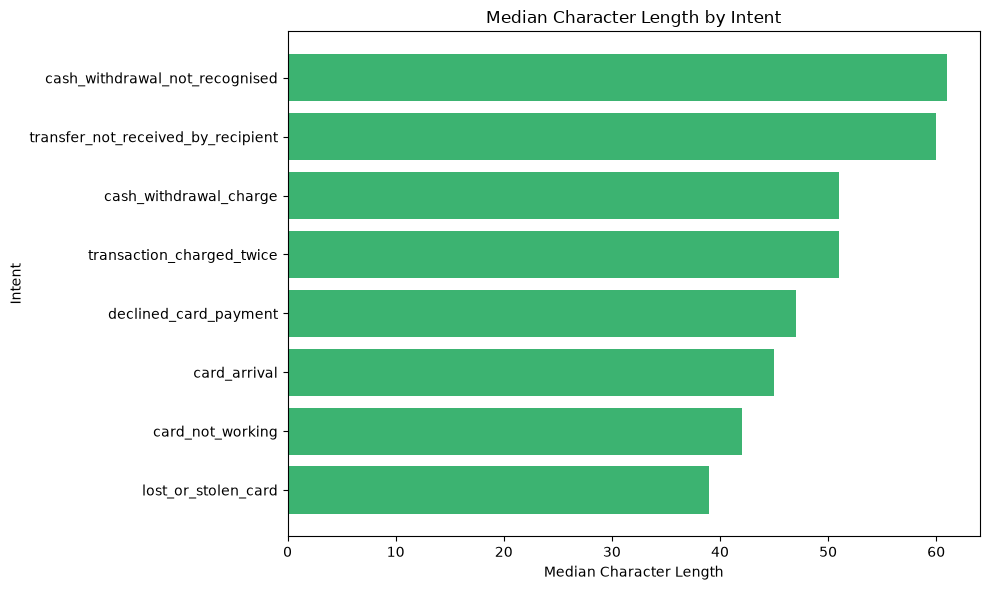

In [88]:
char_length_by_intent = (
    selected_data
    .groupby("category")["char_length"]
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    char_length_by_intent.index,
    char_length_by_intent.values,
    color=SECONDARY_COLOR
)

plt.title("Median Character Length by Intent")
plt.xlabel("Median Character Length")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

### Observation

The median character length shows a clearer difference between some intents than the word-count distribution.

`cash_withdrawal_not_recognised` and `transfer_not_received_by_recipient` have the longest median messages, while `lost_or_stolen_card` and `card_not_working` have the shortest.

However, there is still considerable overlap in message length across intents. Therefore, character length may provide some descriptive information, but the actual words and phrases in the messages are more important for intent classification.

# 4. Train/Test Strategy

The original BANKING77 dataset already provides separate training and test sets. We preserve this split rather than creating a new random split.

After selecting the eight target intents, the same categories are filtered from both datasets. The training set will be used to learn the text representation and train the classifier, while the test set will remain unseen until the final evaluation.

## 4.1 Prepare the Selected Train and Test Sets

The selected intents are filtered from both the training and test datasets so that both sets contain the same target categories.

In [89]:
selected_train = train[train["category"].isin(selected_intents)].copy()
selected_test = test[test["category"].isin(selected_intents)].copy()

## 4.2 Check Class Distribution

The number of samples in each intent is checked separately for the training and test sets to verify that all selected categories are represented.

In [90]:
print("Training set:")
display(selected_train["category"].value_counts())

print("\nTest set:")
display(selected_test["category"].value_counts())

Training set:


category
cash_withdrawal_charge                177
transaction_charged_twice             175
transfer_not_received_by_recipient    171
cash_withdrawal_not_recognised        160
card_arrival                          153
declined_card_payment                 153
card_not_working                      112
lost_or_stolen_card                    82
Name: count, dtype: int64


Test set:


category
card_arrival                          40
card_not_working                      40
lost_or_stolen_card                   40
transfer_not_received_by_recipient    40
declined_card_payment                 40
transaction_charged_twice             40
cash_withdrawal_not_recognised        40
cash_withdrawal_charge                40
Name: count, dtype: int64

## 4.3 Define Features and Labels

For the classification task, the ticket text is used as the input feature, while the intent category is used as the target label.

The text will later be transformed into numerical features using TF-IDF.

In [91]:
X_train = selected_train["text"]
y_train = selected_train["category"]

X_test = selected_test["text"]
y_test = selected_test["category"]

## 4.4 Train/Test Summary

A final summary of the prepared datasets is displayed to verify their sizes and the number of selected intents before model development.

In [92]:
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Number of intents:", y_train.nunique())

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Training samples: 1183
Test samples: 320
Number of intents: 8

Training labels:
category
cash_withdrawal_charge                177
transaction_charged_twice             175
transfer_not_received_by_recipient    171
cash_withdrawal_not_recognised        160
card_arrival                          153
declined_card_payment                 153
card_not_working                      112
lost_or_stolen_card                    82
Name: count, dtype: int64

Test labels:
category
card_arrival                          40
card_not_working                      40
lost_or_stolen_card                   40
transfer_not_received_by_recipient    40
declined_card_payment                 40
transaction_charged_twice             40
cash_withdrawal_not_recognised        40
cash_withdrawal_charge                40
Name: count, dtype: int64


# 5. Keyword-Based Baseline

Before building the machine learning model, a simple keyword-based baseline is created.

This baseline provides a reference point for evaluating whether the machine learning approach can improve classification performance.

## 5.1 Define Keyword Rules

A simple rule-based baseline is created using a small set of distinctive keywords and phrases for each selected intent.

The rules are intentionally simple and focus on obvious cases rather than attempting to capture all possible ways customers may express an intent.

In [93]:
keyword_rules = {
    "cash_withdrawal_charge": [
        "cash withdrawal charge",
        "cash withdrawal fee",
        "charged for cash withdrawal"
    ],

    "transaction_charged_twice": [
        "charged twice",
        "charged two times",
        "charged twice for"
    ],

    "transfer_not_received_by_recipient": [
        "recipient did not receive",
        "recipient hasn't received",
        "recipient has not received",
        "transfer not received"
    ],

    "cash_withdrawal_not_recognised": [
        "cash withdrawal not recognised",
        "cash withdrawal not recognized",
        "cash withdrawal i don't recognize",
        "cash withdrawal I do not recognize"
    ],

    "card_arrival": [
        "card hasn't arrived",
        "card has not arrived",
        "when will my card arrive",
        "where is my card"
    ],

    "declined_card_payment": [
        "card payment was declined",
        "card payment declined",
        "my card payment was declined"
    ],

    "card_not_working": [
    "card not working",
    "my card doesn't work",
    "my card does not work",
    "my card is not working"
    ],

    "lost_or_stolen_card": [
    "lost my card",
    "lost card",
    "stolen card",
    "card was stolen",
    "card has been stolen"
    ]
}

## 5.2 Create the Keyword-Based Prediction Function

A prediction function checks whether any predefined keyword or phrase appears in a customer message.

If a matching phrase is found, the corresponding intent is returned. If no rule matches, the function returns "unknown".

In [94]:
def keyword_predict(text):
    text = text.lower()

    for intent, keywords in keyword_rules.items():
        for keyword in keywords:
            if keyword in text:
                return intent

    return "unknown"

## 5.3 Test the Baseline on Example Messages

A few example messages are tested to verify that the keyword rules work as expected for clear and obvious cases.

In [95]:
example_messages = [
    "I was charged twice for my transaction",
    "My card has been stolen",
    "Why was my card payment declined?",
    "My card is not working",
    "The recipient did not receive my transfer"
]

for message in example_messages:
    print(f"Message: {message}")
    print(f"Prediction: {keyword_predict(message)}")
    print()

Message: I was charged twice for my transaction
Prediction: transaction_charged_twice

Message: My card has been stolen
Prediction: lost_or_stolen_card

Message: Why was my card payment declined?
Prediction: declined_card_payment

Message: My card is not working
Prediction: card_not_working

Message: The recipient did not receive my transfer
Prediction: transfer_not_received_by_recipient



## 5.4 Apply the Baseline to the Test Set

The keyword-based predictor is applied to the unseen test messages.

For each test ticket, the function checks the predefined keyword rules and returns the corresponding intent when a matching phrase is found. If no rule matches, the prediction is set to "unknown".

In [96]:
keyword_predictions = X_test.apply(keyword_predict)

keyword_predictions.head()

0         unknown
1         unknown
2         unknown
3         unknown
4    card_arrival
Name: text, dtype: str

### Understanding the Initial Predictions

Some of the first test messages may be predicted as `"unknown"`. This does not indicate an error in the code.

The keyword-based baseline only recognizes messages that contain one of the predefined keywords or phrases. If none of the rules match a message, the function correctly returns `"unknown"`.

The first five predictions shown above represent only a small sample of the test set. Therefore, they cannot be used to evaluate the overall performance of the baseline. The complete test set will be evaluated in the next step.

## 5.5 Evaluate the Keyword Baseline

The keyword-based predictions are compared with the true test labels to measure the performance of the baseline.

Two measures are considered:

- **Accuracy:** the proportion of all test tickets that are classified correctly.
- **Coverage:** the proportion of test tickets for which the keyword rules produce an intent instead of returning `"unknown"`.

In [97]:
baseline_correct = keyword_predictions == y_test

baseline_accuracy = baseline_correct.mean()

baseline_coverage = (keyword_predictions != "unknown").mean()

print(f"Baseline Accuracy: {baseline_accuracy:.2%}")
print(f"Baseline Coverage: {baseline_coverage:.2%}")

Baseline Accuracy: 11.25%
Baseline Coverage: 11.25%


### Observations

The keyword-based baseline achieved an accuracy of 11.25% and a coverage of 11.25% on the test set.

The low coverage shows that the predefined rules were able to recognize only a small portion of the test messages. The baseline works mainly when customers use explicit phrases that closely match the predefined keywords.

This demonstrates the limitation of exact keyword matching and motivates the use of a machine learning approach that can learn patterns from a wider range of expressions.

The keyword baseline was intentionally kept simple and rule-based, using a limited set of manually defined phrases. Therefore, its low performance mainly reflects the limited coverage of a small rule set rather than the theoretical limits of rule-based systems in general.

## 5.6 Inspect Baseline Successes and Failures

To better understand the limitations of the keyword-based baseline, correct and incorrect predictions are inspected separately.

Looking at individual examples helps identify cases where explicit phrases are successfully recognized and cases where different wording causes the keyword rules to fail.

In [98]:
baseline_results = pd.DataFrame({
    "text": X_test,
    "true_category": y_test,
    "predicted_category": keyword_predictions
})

baseline_results.head()

,text,true_category,predicted_category
0,How do I locate my card?,card_arrival,unknown
1,"I still have not received my new card, I order...",card_arrival,unknown
2,I ordered a card but it has not arrived. Help ...,card_arrival,unknown
3,Is there a way to know when my card will arrive?,card_arrival,unknown
4,My card has not arrived yet.,card_arrival,card_arrival


### Successful Predictions

The correctly classified tickets are examined to identify examples where the predefined keywords or phrases successfully captured the intended category.

In [99]:
baseline_successes = baseline_results[
    baseline_results["true_category"] == baseline_results["predicted_category"]
]

baseline_successes.head(10)

,text,true_category,predicted_category
4,My card has not arrived yet.,card_arrival,card_arrival
24,"My card has not arrived yet, where is it?",card_arrival,card_arrival
30,My card hasn't arrived yet.,card_arrival,card_arrival
366,Why is my card not working?,card_not_working,card_not_working
369,My card does not work,card_not_working,card_not_working
371,Can someone assist me by explaining why my car...,card_not_working,card_not_working
372,Help me. My card doesn't work.,card_not_working,card_not_working
378,My card doesn't work.,card_not_working,card_not_working
445,I lost my card,lost_or_stolen_card,lost_or_stolen_card
446,Oh no! I lost my card! Help!,lost_or_stolen_card,lost_or_stolen_card


### Failed Predictions

The incorrectly classified tickets are examined to identify situations where the keyword rules fail to recognize the customer's intent.

These failures may occur when customers use alternative wording, synonyms, or expressions that are not included in the predefined keyword rules.

In [100]:
baseline_failures = baseline_results[
    baseline_results["true_category"] != baseline_results["predicted_category"]
]

baseline_failures.head(10)

,text,true_category,predicted_category
0,How do I locate my card?,card_arrival,unknown
1,"I still have not received my new card, I order...",card_arrival,unknown
2,I ordered a card but it has not arrived. Help ...,card_arrival,unknown
3,Is there a way to know when my card will arrive?,card_arrival,unknown
5,When will I get my card?,card_arrival,unknown
6,Do you know if there is a tracking number for ...,card_arrival,unknown
7,i have not received my card,card_arrival,unknown
8,still waiting on that card,card_arrival,unknown
9,Is it normal to have to wait over a week for m...,card_arrival,unknown
10,How do I track my card?,card_arrival,unknown


### Observations

The successful predictions show that the keyword baseline works well for messages containing explicit and distinctive phrases that closely match the predefined rules.

However, many failures occur when customers express the same intent using different wording. For example, messages such as "When will I get my card?" and "How do I track my card?" clearly refer to card arrival, but they are not recognized because their wording does not match the predefined phrases.

This demonstrates an important limitation of keyword-based classification: it relies on exact or near-exact phrase matching rather than learning patterns from the text. Therefore, a more flexible approach is needed to handle different ways of expressing the same intent.

## 6. TF-IDF Vectorization

Machine learning models cannot directly work with raw text, so customer messages need to be converted into numerical features.

TF-IDF (Term Frequency–Inverse Document Frequency) is used to represent text numerically by assigning higher weights to terms that are important within a document and less common across the collection of documents.

In this project, TF-IDF features will be used as the input to the Logistic Regression classifier.

### 6.1 Import and Initialize the TF-IDF Vectorizer

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [102]:
tfidf = TfidfVectorizer()

### 6.2 Fit TF-IDF on the Training Data

The TF-IDF vectorizer is fitted only on the training messages.

During fitting, the vectorizer learns the vocabulary and the document-frequency information required to calculate IDF values.

The test data is not used during this learning step in order to prevent data leakage.

In [103]:
tfidf.fit(X_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

### 6.3 Transform the Training Data

After learning the vocabulary and IDF values, the training messages are transformed into numerical TF-IDF vectors.

Each row represents a ticket, and each column represents a feature corresponding to a term in the learned vocabulary.

In [104]:
X_train_tfidf = tfidf.transform(X_train)

X_train_tfidf.shape

(1183, 850)

### 6.4 Transform the Test Data

The test messages are transformed using the TF-IDF vocabulary and IDF values learned from the training data.

The vectorizer is not fitted again on the test set. This ensures that information from the test data does not influence the learned representation.

In [105]:
X_test_tfidf = tfidf.transform(X_test)

X_test_tfidf.shape

(320, 850)

### 6.5 Inspect the Learned Vocabulary

The learned vocabulary can be inspected to understand how the text has been converted into numerical features.

Each unique term in the vocabulary corresponds to a feature in the TF-IDF representation.

In [106]:
print("Number of features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 features:")
print(tfidf.get_feature_names_out()[:20])

Number of features: 850

First 20 features:
['200' '500' 'able' 'about' 'absolutely' 'accept' 'accepted' 'access'
 'accidentally' 'according' 'account' 'accurate' 'actions' 'activity'
 'actual' 'actually' 'added' 'additional' 'advise' 'afford']


### 6.6 Inspect a Single TF-IDF Representation

A single ticket is converted into a TF-IDF vector to illustrate how individual words are represented numerically.

In [107]:
sample_vector = X_train_tfidf[0]

print("Number of features:", sample_vector.shape[1])
print("Number of non-zero values:", sample_vector.nnz)

Number of features: 850
Number of non-zero values: 6


### 6.7 Inspect Important Terms in a Ticket

The non-zero TF-IDF values of a single ticket are examined to identify which terms receive higher weights in that document.

In [108]:
feature_names = tfidf.get_feature_names_out()

row = X_train_tfidf[0].toarray().flatten()

non_zero_indices = row.nonzero()[0]

terms_and_scores = sorted(
    [(feature_names[i], row[i]) for i in non_zero_indices],
    key=lambda x: x[1],
    reverse=True
)

terms_and_scores

[('waiting', np.float64(0.5982359301717457)),
 ('still', np.float64(0.472875163850685)),
 ('am', np.float64(0.45766156534621166)),
 ('on', np.float64(0.3658044334245266)),
 ('card', np.float64(0.2103970026038214)),
 ('my', np.float64(0.1759800007156442))]

### TF-IDF Summary

TF-IDF converts text into numerical features by assigning weights to terms according to their importance within a document and their frequency across the corpus.

In this project, the TF-IDF vectorizer is fitted only on the training data. Both training and test messages are then transformed using the learned vocabulary and IDF values.

The resulting numerical features can be used as input to the Logistic Regression classifier.

## 7. Logistic Regression and Pipeline

Logistic Regression is a supervised machine learning algorithm that can be used for text classification.

In this project, the TF-IDF representation of customer messages will be used as the input features, and Logistic Regression will learn to predict the selected customer support intents.

A scikit-learn Pipeline is used to combine text vectorization and classification into a single workflow.

### 7.1 Import the Required Tools

The required scikit-learn components are imported for building the text classification pipeline.

`TfidfVectorizer` converts text into numerical features, `LogisticRegression` performs the classification, and `Pipeline` connects these steps into one workflow.

In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

### 7.2 Build the Classification Pipeline

The pipeline combines TF-IDF vectorization and Logistic Regression.

The first step transforms the text into TF-IDF features. The second step uses these features to train a Logistic Regression classifier.

This structure keeps preprocessing and model training together and helps prevent inconsistent transformations between training and test data.

In [110]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [134]:
import joblib
from pathlib import Path

MODEL_PATH = Path("..") / "model.pkl"

joblib.dump(model, MODEL_PATH)

print(f"Model saved successfully to: {MODEL_PATH.resolve()}")

Model saved successfully to: D:\3. projects\9. study group archive\پروژه سوم\project-03-AI-Tickeet-Classifier\model.pkl


### 7.3 Train the Pipeline

The pipeline is trained using the training messages and their corresponding intent labels.

During `fit()`, the TF-IDF vectorizer learns its vocabulary from the training data and transforms the training messages. The Logistic Regression classifier then learns the relationship between the resulting features and the intent labels.

In [112]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](8,)","['card_arrival','card_not_working','cash_withdrawal_charge',..., 'lost_or_stolen_card','transaction_charged_twice', 'transfer_not_received_by_recipient']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


### 7.4 Generate Predictions

The trained pipeline is used to predict the intents of the unseen test messages.

The test messages are passed directly to the pipeline. The pipeline applies the already learned TF-IDF transformation and then uses the trained Logistic Regression classifier to generate predictions.

In [113]:
y_pred = model.predict(X_test)

### 7.5 Inspect Sample Predictions

A few test messages and their predicted intents are displayed to verify that the trained model is producing reasonable outputs.

In [114]:
prediction_examples = pd.DataFrame({
    "text": X_test,
    "true_category": y_test,
    "predicted_category": y_pred
})

prediction_examples.head(10)

,text,true_category,predicted_category
0,How do I locate my card?,card_arrival,card_not_working
1,"I still have not received my new card, I order...",card_arrival,card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival
4,My card has not arrived yet.,card_arrival,card_arrival
5,When will I get my card?,card_arrival,card_arrival
6,Do you know if there is a tracking number for ...,card_arrival,card_arrival
7,i have not received my card,card_arrival,card_arrival
8,still waiting on that card,card_arrival,card_arrival
9,Is it normal to have to wait over a week for m...,card_arrival,card_arrival


### 7.6 Prediction Distribution

The distribution of the predicted intents is examined to check whether the model is producing predictions across the selected categories.

This provides a simple sanity check before calculating the formal evaluation metrics.

In [115]:
prediction_counts = pd.Series(y_pred).value_counts()

prediction_counts

cash_withdrawal_not_recognised        43
transaction_charged_twice             42
card_not_working                      41
declined_card_payment                 40
transfer_not_received_by_recipient    40
card_arrival                          39
cash_withdrawal_charge                39
lost_or_stolen_card                   36
Name: count, dtype: int64

### 7.7 Quick Sanity Check

The first few predictions are compared with their true labels to verify that the model has been trained and can produce predictions for unseen messages.

A small sample is only used as a sanity check; overall model performance will be evaluated using quantitative metrics in the next section.

In [116]:
for text, true_label, predicted_label in zip(
    X_test.head(5),
    y_test.head(5),
    y_pred[:5]
):
    print(f"Message: {text}")
    print(f"True: {true_label}")
    print(f"Predicted: {predicted_label}")
    print("-" * 50)

Message: How do I locate my card?
True: card_arrival
Predicted: card_not_working
--------------------------------------------------
Message: I still have not received my new card, I ordered over a week ago.
True: card_arrival
Predicted: card_arrival
--------------------------------------------------
Message: I ordered a card but it has not arrived. Help please!
True: card_arrival
Predicted: card_arrival
--------------------------------------------------
Message: Is there a way to know when my card will arrive?
True: card_arrival
Predicted: card_arrival
--------------------------------------------------
Message: My card has not arrived yet.
True: card_arrival
Predicted: card_arrival
--------------------------------------------------


### Observation

The model correctly classifies most of the inspected examples, but some messages are still misclassified. For example, "How do I locate my card?" is incorrectly predicted as `card_not_working` instead of `card_arrival`.

The prediction distribution also shows that the model does not assign exactly the same number of samples to each intent. This is expected because the classifier makes predictions based on learned text patterns rather than the known class distribution.

A more reliable evaluation using Accuracy, Precision, Recall, F1-score, and a Confusion Matrix will be performed in the next section.

## 8. Model Evaluation

After training the Logistic Regression classifier, its performance is evaluated on the unseen test set.

Several evaluation metrics are used to measure different aspects of classification performance, including Accuracy, Precision, Recall, and F1-score.

A Confusion Matrix is also used to analyze which intents are correctly classified and which intents are confused with each other.

### 8.1 Accuracy

Accuracy measures the proportion of test samples that are classified correctly.

It provides an overall measure of how often the model makes the correct prediction across all selected intents.

In [117]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 97.19%


### 8.2 Precision, Recall, and F1-score

Accuracy alone does not show how well the model performs for each individual intent.

Precision measures how often the predictions for an intent are correct, while Recall measures how many of the actual samples belonging to an intent are successfully identified.

F1-score combines Precision and Recall into a single metric and provides a balanced measure of classification performance.

In [118]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_weighted = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Weighted Precision: {precision_weighted:.2%}")
print(f"Weighted Recall: {recall_weighted:.2%}")
print(f"Weighted F1-score: {f1_weighted:.2%}")
print(f"Macro-F1: {f1_macro:.2%}")

Weighted Precision: 97.31%
Weighted Recall: 97.19%
Weighted F1-score: 97.18%
Macro-F1: 97.18%


### 8.3 Classification Report

The classification report provides Precision, Recall, F1-score, and the number of test samples for each intent.

This allows us to compare the model's performance across the eight selected categories rather than relying only on overall metrics.

In [119]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

                                    precision    recall  f1-score   support

                      card_arrival      1.000     0.975     0.987        40
                  card_not_working      0.927     0.950     0.938        40
            cash_withdrawal_charge      1.000     0.975     0.987        40
    cash_withdrawal_not_recognised      0.930     1.000     0.964        40
             declined_card_payment      0.975     0.975     0.975        40
               lost_or_stolen_card      1.000     0.900     0.947        40
         transaction_charged_twice      0.952     1.000     0.976        40
transfer_not_received_by_recipient      1.000     1.000     1.000        40

                          accuracy                          0.972       320
                         macro avg      0.973     0.972     0.972       320
                      weighted avg      0.973     0.972     0.972       320



### Observation

The Logistic Regression model achieved an overall accuracy of 97.2% on the 320 test samples.

Most intents achieved high Precision, Recall, and F1-scores. The `transfer_not_received_by_recipient` intent achieved the highest F1-score of 1.000, while `card_not_working` had the lowest F1-score at 0.938.

The relatively lower Recall for `lost_or_stolen_card` (0.900) indicates that some messages belonging to this intent were classified as other categories.

Overall, the results indicate that the TF-IDF and Logistic Regression pipeline performs very well on the selected intents. The Confusion Matrix will be used to examine the specific misclassifications in more detail.

### 8.4 Confusion Matrix

A Confusion Matrix shows how the model's predictions are distributed across the different intents.

Each row represents the true intent, while each column represents the predicted intent.

Correct predictions appear on the diagonal, while off-diagonal values represent misclassifications.

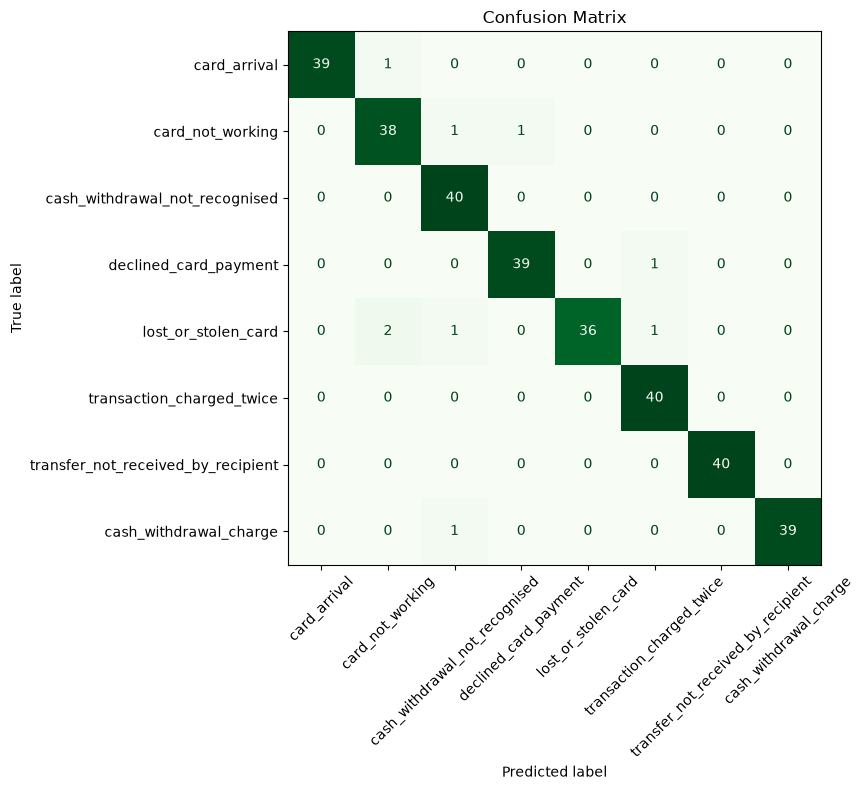

In [120]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=selected_intents
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_intents
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Greens",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Observation

The Confusion Matrix shows that most predictions lie on the main diagonal, indicating that the model correctly classifies the majority of test samples.

Only 9 out of 320 test samples are misclassified. The largest single confusion occurs for `lost_or_stolen_card`, where two samples are classified as `card_not_working`.

Other errors are isolated across several intent pairs, such as `card_arrival` being confused with `card_not_working` and `cash_withdrawal_charge` being confused with `cash_withdrawal_not_recognised`.

Overall, the small number of off-diagonal values confirms the strong performance of the classifier, while also highlighting specific cases for further error analysis.

### 8.5 F1-score by Intent

The F1-score of each intent is visualized to compare classification performance across the eight selected categories.

This helps identify intents that are relatively easy or difficult for the model to classify.

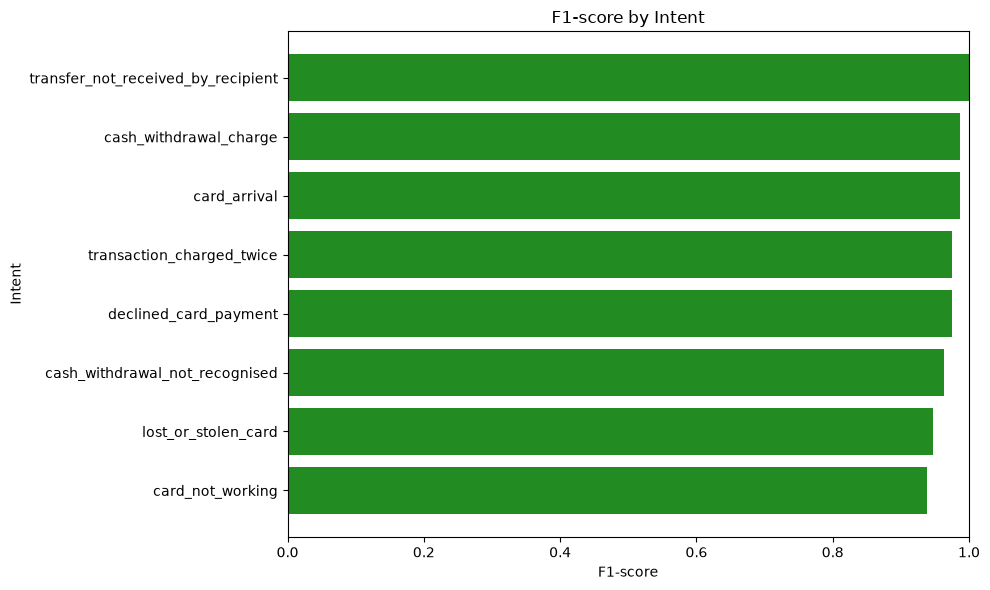

In [121]:
from sklearn.metrics import f1_score

f1_scores = f1_score(
    y_test,
    y_pred,
    labels=selected_intents,
    average=None
)

f1_df = pd.DataFrame({
    "intent": selected_intents,
    "f1_score": f1_scores
}).sort_values("f1_score")

plt.figure(figsize=(10, 6))

plt.barh(
    f1_df["intent"],
    f1_df["f1_score"],
    color=PRIMARY_COLOR
)

plt.xlabel("F1-score")
plt.ylabel("Intent")
plt.title("F1-score by Intent")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

### Observation

The F1-scores are high across all eight intents, ranging from 0.938 to 1.000.

`transfer_not_received_by_recipient` achieves the highest F1-score of 1.000, while `card_not_working` has the lowest F1-score at 0.938.

The relatively lower scores for `card_not_working` and `lost_or_stolen_card` are consistent with the Confusion Matrix, where these intents account for several of the observed misclassifications.

Overall, the model performs consistently well across the selected intents rather than relying on strong performance in only a few categories.

### 8.6 Baseline vs. Machine Learning Model

The performance of the keyword-based baseline is compared with the Logistic Regression model using Accuracy.

This comparison shows whether the machine learning approach provides a meaningful improvement over the simple rule-based baseline.

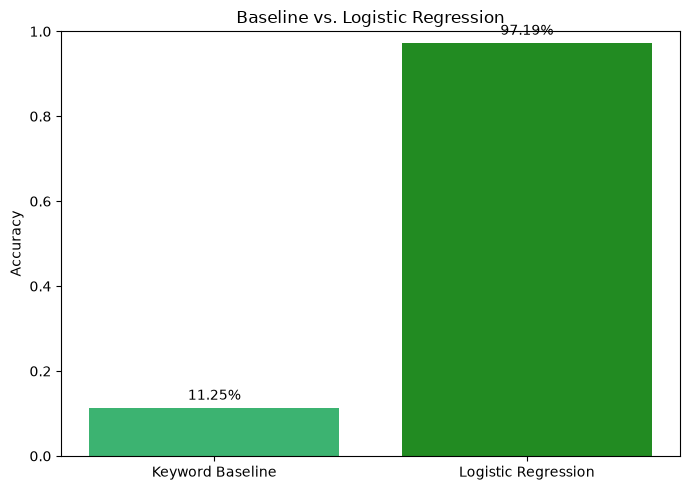

In [122]:
comparison = pd.DataFrame({
    "Model": [
        "Keyword Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
    color=[SECONDARY_COLOR, PRIMARY_COLOR]
)

plt.ylabel("Accuracy")
plt.title("Baseline vs. Logistic Regression")
plt.ylim(0, 1)

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Observation

The Logistic Regression model significantly outperforms the keyword-based baseline.

The keyword baseline achieved an accuracy of 11.25%, while the Logistic Regression model achieved 97.19% accuracy on the test set. This large improvement shows that learning patterns from the training data is much more effective than relying on a small set of manually defined keywords for this classification task.

However, the comparison is based on Accuracy alone; class-level metrics and error analysis are also considered to provide a more complete evaluation.

## 9. Error Analysis

Even a high-performing classifier can make incorrect predictions. Error analysis helps identify the types of messages that are difficult for the model and reveals patterns behind misclassification.

In this section, some incorrect predictions are manually inspected to identify common sources of error and commonly confused intents.

### 9.1 Incorrect Predictions

First, the test predictions are compared with their true categories. Only incorrectly classified messages are selected for further inspection.

In [123]:
error_analysis = pd.DataFrame({
    "text": X_test,
    "true_category": y_test,
    "predicted_category": y_pred
})

errors = error_analysis[
    error_analysis["true_category"] != error_analysis["predicted_category"]
]

print(f"Number of incorrect predictions: {len(errors)}")

Number of incorrect predictions: 9


### 9.2 Manual Inspection of Errors

The incorrect predictions are displayed below for manual inspection. Since the model produced only nine incorrect predictions on the test set, all available errors are inspected rather than selecting only a subset.

The true and predicted intents are compared to identify possible linguistic similarities, ambiguity, and patterns behind the misclassifications.

In [124]:
errors.head(20)

,text,true_category,predicted_category
0,How do I locate my card?,card_arrival,card_not_working
360,I've tried my card a bunch of times and it nev...,card_not_working,declined_card_payment
368,How do I unblock my card using the app?,card_not_working,cash_withdrawal_not_recognised
453,Is a copy of the police report necessary for c...,lost_or_stolen_card,transaction_charged_twice
461,"Someone stole my wallet earlier today, not sur...",lost_or_stolen_card,card_not_working
467,My card was taken from me,lost_or_stolen_card,cash_withdrawal_not_recognised
477,Are you able to locate my card?,lost_or_stolen_card,card_not_working
1828,"Hello, I am facing the issue with my new card ...",declined_card_payment,transaction_charged_twice
2917,"When I got cash, I'm pretty sure there was a g...",cash_withdrawal_charge,cash_withdrawal_not_recognised


### 9.3 Error Analysis Findings

Several mistakes involve card-related intents. For example, `card_arrival` was confused with `card_not_working`, while `lost_or_stolen_card` was sometimes confused with `card_not_working` or `cash_withdrawal_not_recognised`. These errors may occur because some messages mention a card without explicitly stating the intended issue.

Another confusion occurred between `cash_withdrawal_charge` and `cash_withdrawal_not_recognised`. Both intents contain language related to cash withdrawals, but one concerns an additional charge while the other concerns an unrecognized transaction.

Overall, the errors suggest that the model performs well when the message contains distinctive intent-specific terms, but ambiguous or short card-related messages can be more difficult to classify.

## 10. Business-Aware Error Analysis

Model performance should not be evaluated only by counting the number of incorrect predictions. In a customer-support system, different types of mistakes can have different operational consequences.

Some intents may require faster or more careful handling because they are related to card security, unauthorized transactions, or payment problems. For these cases, a misclassified ticket may be more costly than an error involving a routine service request.

Therefore, this section considers the potential business impact of different types of classification errors and identifies which evaluation metric should receive greater attention for higher-risk intents.

### 10.1 Business-Critical Intents

For this prototype, the following three intents are considered potentially more business-critical:

- `lost_or_stolen_card`
- `cash_withdrawal_not_recognised`
- `declined_card_payment`

The first two are related to card security and potentially unauthorized activity, while `declined_card_payment` concerns a payment failure that may directly affect a customer's ability to complete a transaction.

This prioritization is a business-oriented assumption for the prototype. The dataset itself does not provide information about financial loss, customer impact, or operational severity, so these intents are considered potentially higher-risk rather than objectively more costly.

### 10.2 Why False Negatives Can Matter More

A False Negative occurs when a ticket actually belongs to a particular intent, but the model assigns it to another category.

For example, if a message about a lost or stolen card is classified as `card_not_working`, the ticket may be routed to a general card-support workflow instead of receiving the attention associated with a potentially security-related issue.

Similarly, if an unrecognized cash withdrawal is assigned to another category, a potentially unauthorized transaction may not be identified correctly.

For these cases, missing a real security-related or payment-related issue may be more costly than incorrectly flagging an unrelated ticket as a high-priority case.

### 10.3 Which Metric Deserves More Attention?

For potentially business-critical intents, Recall deserves particular attention because it measures how many of the actual cases belonging to an intent are successfully identified by the model.

A low Recall means that some real cases are missed and assigned to other intents. In a support-routing system, these missed cases may result in inappropriate routing or delayed handling.

Precision remains important because a low Precision would generate more false alarms and could increase the workload of support agents. However, for security-related or potentially sensitive cases, avoiding missed cases can be considered the higher-priority concern.

Therefore, Recall should be monitored carefully for the selected business-critical intents, while Precision and F1-score should still be considered to maintain a reasonable balance.

## 11. Prediction Function

The trained TF-IDF and Logistic Regression pipeline can be used to classify new customer messages.

A reusable function is created to accept a new message and return the predicted intent together with a confidence score. The confidence score is based on the highest probability assigned by the Logistic Regression classifier.

> **Note:** The confidence score represents the highest class probability returned by the Logistic Regression model. It should be interpreted as a model-based confidence signal rather than a guaranteed probability that the prediction is correct. Proper probability calibration would be required for stronger probabilistic interpretation.

In [125]:
def predict_intent(message):
    predicted_intent = model.predict([message])[0]
    
    probabilities = model.predict_proba([message])[0]
    confidence = probabilities.max()
    
    return predicted_intent, confidence

### 11.1 Testing the Prediction Function

The function is tested with several new customer messages to verify that it returns both a predicted intent and a confidence score.

In [126]:
test_messages = [
    "I lost my card",
    "Why was I charged twice?",
    "My cash withdrawal is not mine",
    "My card payment was declined"
]

for message in test_messages:
    intent, confidence = predict_intent(message)
    
    print(f"Message: {message}")
    print(f"Predicted intent: {intent}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 50)

Message: I lost my card
Predicted intent: lost_or_stolen_card
Confidence: 85.01%
--------------------------------------------------
Message: Why was I charged twice?
Predicted intent: transaction_charged_twice
Confidence: 90.35%
--------------------------------------------------
Message: My cash withdrawal is not mine
Predicted intent: cash_withdrawal_not_recognised
Confidence: 80.16%
--------------------------------------------------
Message: My card payment was declined
Predicted intent: declined_card_payment
Confidence: 98.83%
--------------------------------------------------


## 12. Human Review Rule

A model prediction should not always be treated as equally reliable. Even when the classifier assigns an intent, some predictions may have lower confidence and therefore deserve additional review.

To make the system safer in practical use, a confidence threshold can be introduced. Predictions above the threshold are accepted automatically, while predictions below it are flagged for human review.

### 12.1 Confidence Threshold

For this prototype, a confidence threshold of 80% is proposed as an initial human-review rule.

Predictions with confidence equal to or above 80% are accepted automatically, while predictions below 80% are flagged for human review.

This threshold is a practical starting point rather than an empirically optimized value. In a production system, the threshold should be tuned using validation data and business costs associated with false positives and false negatives.

### 12.2 Implementing the Human Review Rule

The prediction function is extended to compare the model confidence with the selected threshold. If the confidence is below the threshold, the message is flagged for human review.

In [127]:
CONFIDENCE_THRESHOLD = 0.80

def predict_with_review(message):
    predicted_intent = model.predict([message])[0]
    
    probabilities = model.predict_proba([message])[0]
    confidence = probabilities.max()
    
    if confidence < CONFIDENCE_THRESHOLD:
        decision = "Human review required"
    else:
        decision = "Automatic classification"
    
    return predicted_intent, confidence, decision

### Threshold Selection

A confidence threshold of 0.80 is used as a simple human-review rule. Predictions below this threshold are considered uncertain and are deferred to a human support agent.

This threshold is a practical prototype choice rather than an optimized business threshold. In a real deployment, the threshold should be selected using validation data, calibration analysis, and the relative cost of different types of misclassification.

In [128]:
test_messages = [
    "I lost my card",
    "Why was I charged twice?",
    "My cash withdrawal is not mine",
    "My card payment was declined"
]

for message in test_messages:
    intent, confidence, decision = predict_with_review(message)
    
    print(f"Message: {message}")
    print(f"Predicted intent: {intent}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Decision: {decision}")
    print("-" * 50)

Message: I lost my card
Predicted intent: lost_or_stolen_card
Confidence: 85.01%
Decision: Automatic classification
--------------------------------------------------
Message: Why was I charged twice?
Predicted intent: transaction_charged_twice
Confidence: 90.35%
Decision: Automatic classification
--------------------------------------------------
Message: My cash withdrawal is not mine
Predicted intent: cash_withdrawal_not_recognised
Confidence: 80.16%
Decision: Automatic classification
--------------------------------------------------
Message: My card payment was declined
Predicted intent: declined_card_payment
Confidence: 98.83%
Decision: Automatic classification
--------------------------------------------------


### Observation

All four test messages received confidence scores at or above the 80% threshold and were therefore classified automatically.

The lowest confidence was 80.16% for `cash_withdrawal_not_recognised`, which is only slightly above the threshold. This shows that a message can still be accepted automatically while having noticeably lower confidence than clearer cases such as `declined_card_payment`.

The 80% threshold is an initial operational choice and should be further tuned using validation data and business costs in a production system.

## 13. Top TF-IDF Terms

TF-IDF assigns higher weights to terms that are important within a document while being relatively less common across the overall corpus.

In this section, we examine the terms with the highest TF-IDF weights for each selected intent. This provides an interpretable view of the words that are most strongly associated with the text representation used by the model.

The analysis focuses on the eight selected intents and displays the top 10 terms for each intent.

### 13.1 Extracting TF-IDF Features

The trained TF-IDF vectorizer is accessed from the pipeline. Its vocabulary contains the features learned from the training data.

The feature names are then used to identify the terms associated with each TF-IDF feature.

In [129]:
tfidf = model.named_steps["tfidf"]
classifier = model.named_steps["classifier"]

feature_names = tfidf.get_feature_names_out()

print(f"Number of TF-IDF features: {len(feature_names)}")

Number of TF-IDF features: 850


### 13.2 Finding the Most Important Terms for Each Intent

To identify the terms that are most representative of each intent, the TF-IDF values of the training messages belonging to each intent are averaged.

The terms with the highest average TF-IDF values are treated as the most representative terms for that intent.

In [130]:
import numpy as np
import pandas as pd

X_train_tfidf = tfidf.transform(X_train)

y_train_array = y_train.to_numpy()

top_terms = {}

for intent in selected_intents:
    intent_mask = (y_train_array == intent)
    
    mean_tfidf = X_train_tfidf[intent_mask].mean(axis=0)
    mean_tfidf = np.asarray(mean_tfidf).ravel()
    
    top_indices = mean_tfidf.argsort()[::-1][:10]
    
    top_terms[intent] = [
        (feature_names[i], mean_tfidf[i])
        for i in top_indices
    ]

### 13.3 Top TF-IDF Terms by Intent

The ten terms with the highest average TF-IDF weights are displayed for each intent.

These terms provide an interpretable summary of the vocabulary that is particularly prominent within each category. They describe the text representation of the selected intents and should not be interpreted as direct feature importance scores from the Logistic Regression classifier.

In [131]:
for intent, terms in top_terms.items():
    print(f"\n{intent}")
    print("-" * len(intent))
    
    for term, score in terms:
        print(f"{term:<25} {score:.4f}")


card_arrival
------------
card                      0.1578
new                       0.1052
my                        0.0954
track                     0.0824
the                       0.0731
to                        0.0731
sent                      0.0653
me                        0.0605
you                       0.0536
is                        0.0530

card_not_working
----------------
card                      0.1545
my                        0.1179
working                   0.1005
work                      0.0979
use                       0.0730
to                        0.0677
is                        0.0639
do                        0.0618
not                       0.0546
can                       0.0539

cash_withdrawal_not_recognised
------------------------------
withdrawal                0.1293
cash                      0.1265
app                       0.0974
that                      0.0932
my                        0.0910
is                        0.0709
didn             

### 13.4 Visualization of Top TF-IDF Terms

The most representative TF-IDF terms are visualized for each intent using horizontal bar charts.

Higher bars indicate terms with higher average TF-IDF weights within the corresponding intent. These visualizations help identify words that distinguish the selected support categories and provide an interpretable view of the features used by the text representation.

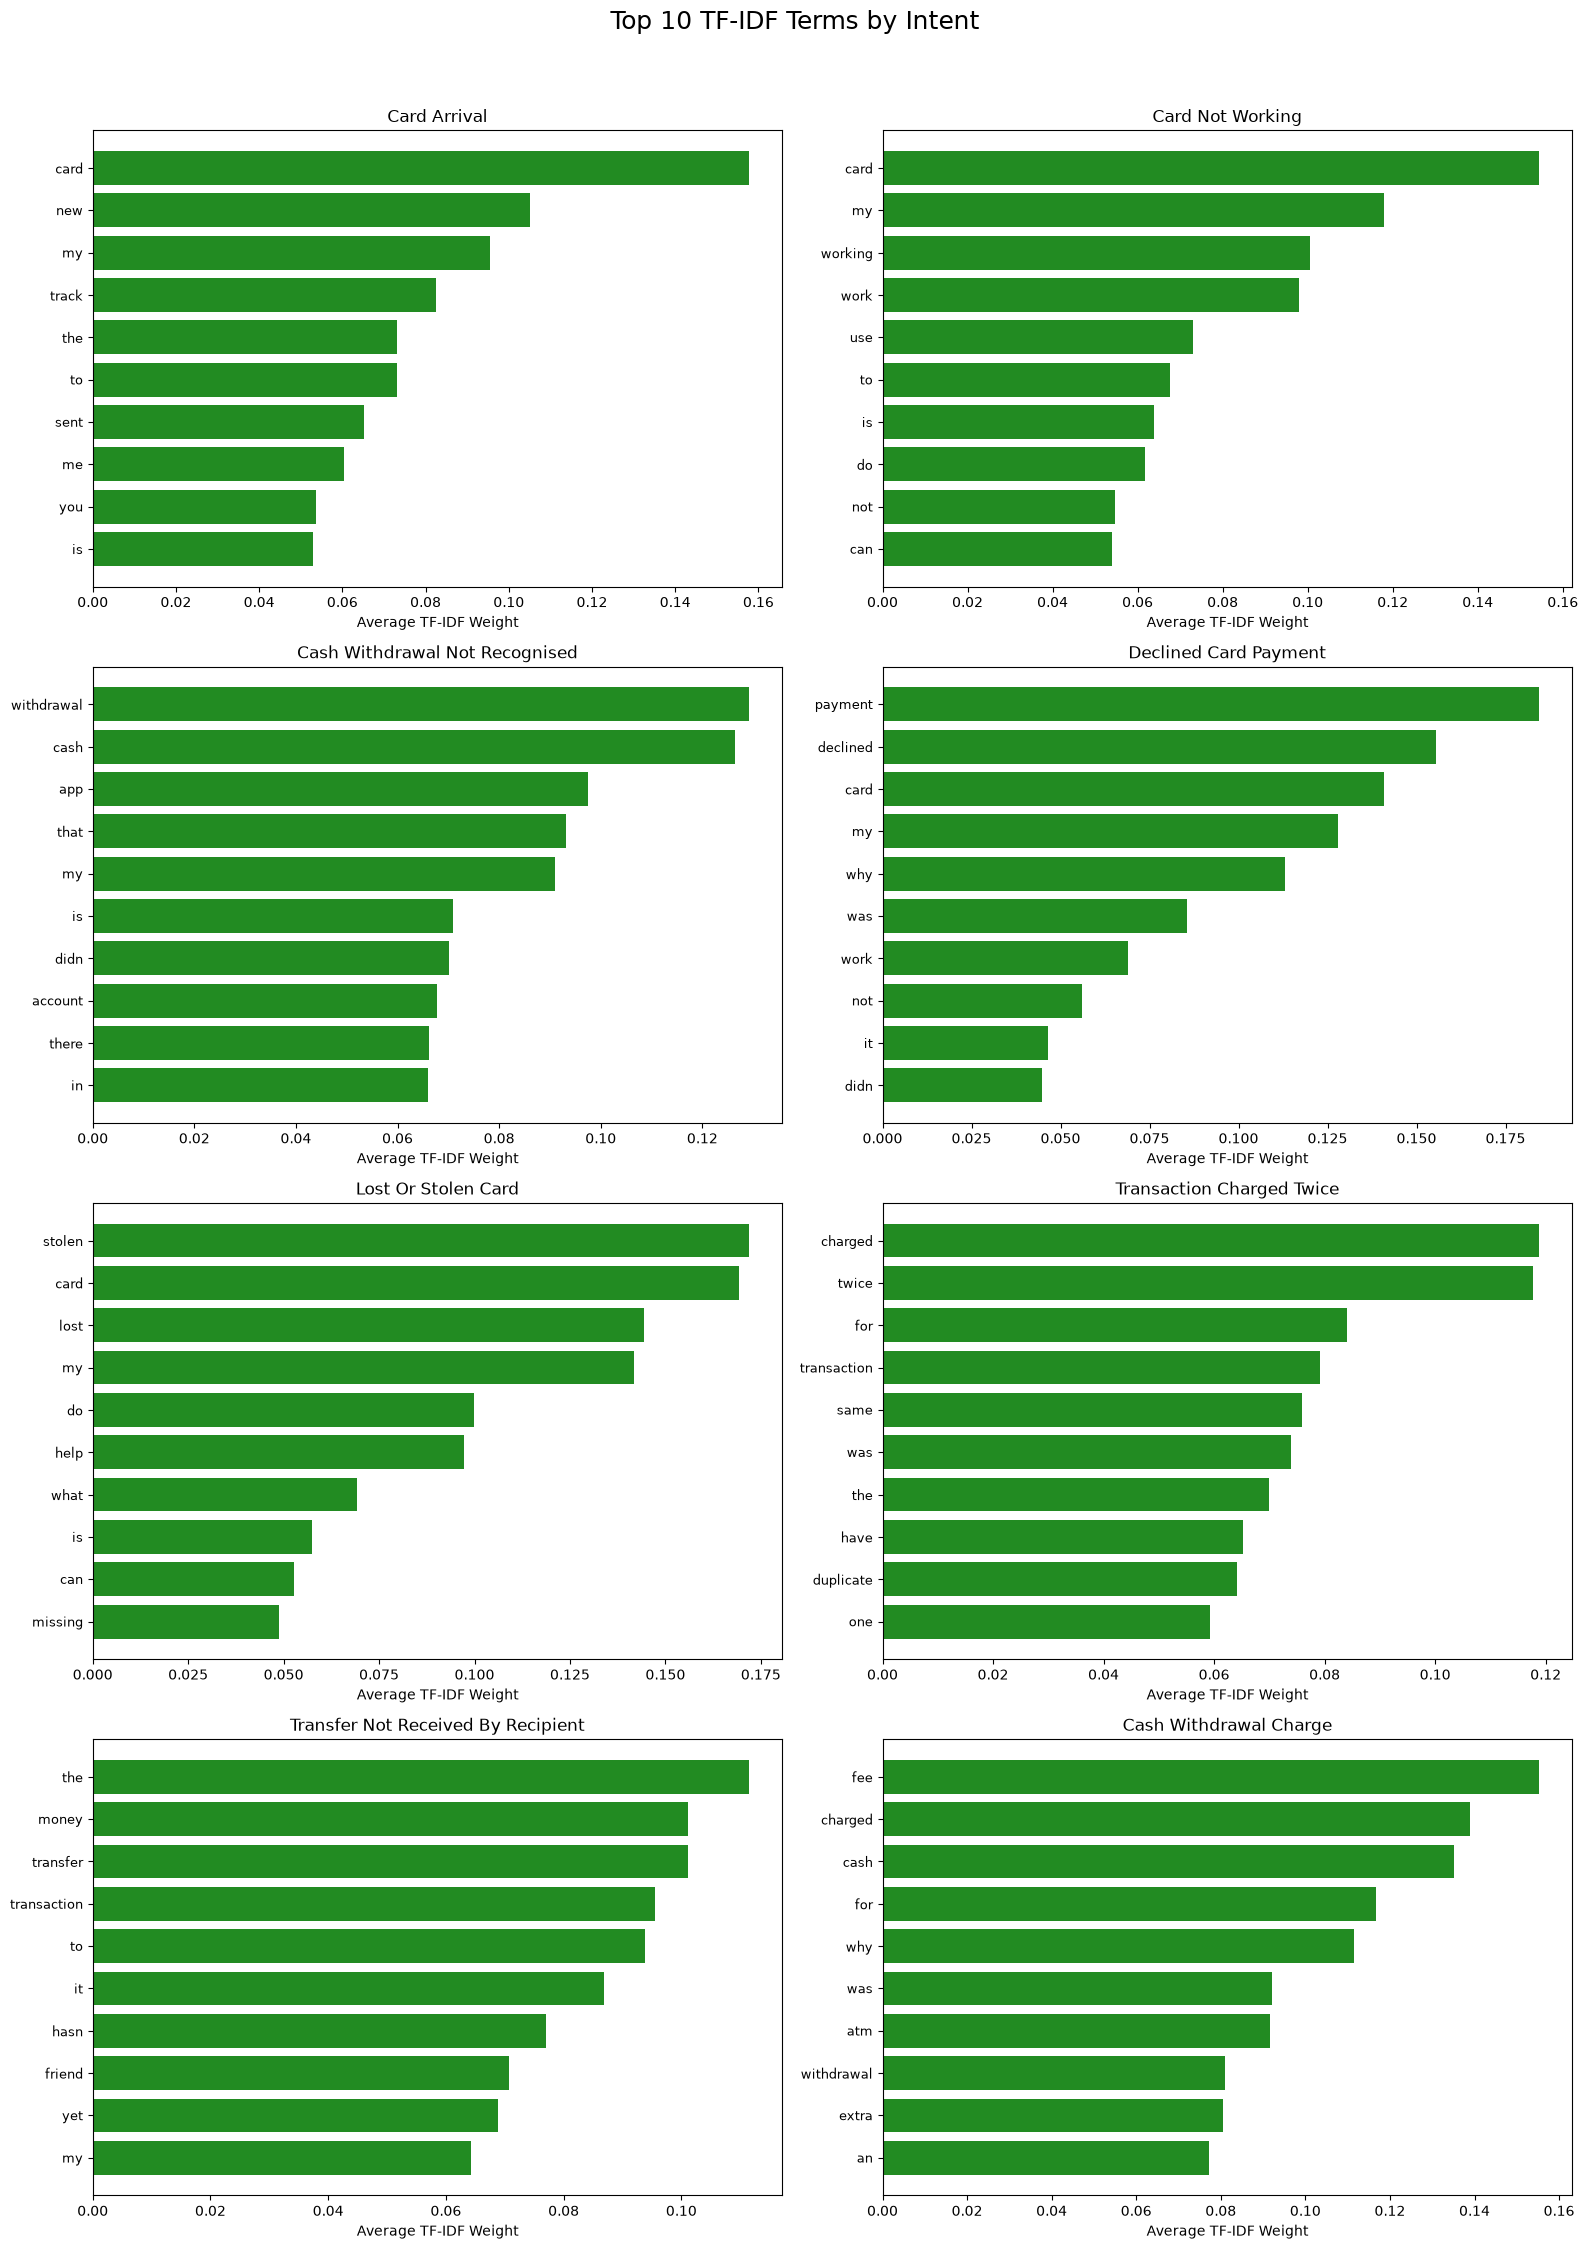

In [132]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 22)
)

axes = axes.flatten()

for ax, (intent, terms) in zip(axes, top_terms.items()):
    terms_reversed = terms[::-1]
    
    words = [term for term, score in terms_reversed]
    scores = [score for term, score in terms_reversed]
    
    ax.barh(words, scores, color=PRIMARY_COLOR)
    ax.set_title(intent.replace("_", " ").title())
    ax.set_xlabel("Average TF-IDF Weight")
    
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle(
    "Top 10 TF-IDF Terms by Intent",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

### Observation

The TF-IDF analysis shows that several intents have highly distinctive terms that closely match their underlying support topics.

For example, `lost_or_stolen_card` is strongly associated with terms such as `stolen`, `lost`, and `card`, while `transaction_charged_twice` is characterized by terms such as `charged`, `twice`, and `duplicate`. Similarly, `declined_card_payment` is strongly associated with `payment` and `declined`.

The `cash_withdrawal_not_recognised` and `cash_withdrawal_charge` intents also share terms related to cash withdrawals, which reflects their semantic similarity and may help explain some of the confusion observed during error analysis.

Overall, the extracted TF-IDF terms provide an interpretable view of the vocabulary that represents each intent, while also highlighting similarities between closely related categories.

## 14. Final Conclusions & Limitations

This project developed an interpretable NLP prototype for automatic customer-support ticket classification.

Using a selected subset of eight intents from the BANKING77 dataset, the project followed a complete text-classification workflow: data understanding, intent selection, text EDA, train/test separation, a keyword-based baseline, TF-IDF feature extraction, Logistic Regression, model evaluation, error analysis, prediction with confidence, and a human-review rule.

The final system is designed as a prototype for understanding and routing customer-support requests rather than as a production-ready system.

### 14.1 Key Results

The final TF-IDF + Logistic Regression model achieved an accuracy of 97.19% on the 320-sample test set.

The model achieved:

- Precision: 97.31%
- Recall: 97.19%
- F1-score: 97.18%
- Macro-F1: 97.2%

The classification report showed consistently strong performance across the eight selected intents, although some confusion remained between semantically related categories.

Compared with the keyword-based baseline, which achieved 11.25% accuracy, the machine learning approach provided a substantial improvement in classification performance.

This result suggests that learning patterns from the training data is considerably more effective than relying only on a small set of manually defined keywords for this task.

### Key Takeaway

The results suggest that classical NLP methods can provide strong performance for this constrained intent-classification task. However, the limited intent subset, dataset scope, and absence of probability calibration mean that the system should be treated as an experimental prototype rather than a production routing system.

### 14.2 Error Analysis Findings

The final model produced 9 incorrect predictions out of 320 test samples.

Manual inspection of these errors showed that several mistakes occurred between semantically related intents. For example, messages concerning lost or stolen cards could be confused with more general card-related problems, while some cash-withdrawal and transaction-related messages shared overlapping vocabulary.

These errors suggest that the remaining mistakes are not necessarily caused by completely unrelated predictions. Instead, some arise from the linguistic similarity between neighboring support categories.

The confusion matrix and per-class metrics also showed that the model performed strongly across all eight intents, with F1-scores ranging from 0.938 to 1.000.

### 14.3 Business Implications

The results indicate that an automated routing system could potentially handle many routine support messages without requiring manual classification for every ticket.

However, not all intents should necessarily be treated equally. Intents such as `lost_or_stolen_card` and `cash_withdrawal_not_recognised` may involve security-related or potentially unauthorized activity, while `declined_card_payment` may directly affect a customer's ability to complete a payment.

For such cases, Recall deserves particular attention because missing a real case may lead to inappropriate routing or delayed handling.

The human-review rule introduced in this project provides an additional safety mechanism by sending low-confidence predictions for manual inspection rather than automatically accepting every prediction.

### 14.4 Confidence-Based Human Review

A confidence threshold of 80% was introduced as an initial operational rule.

Predictions with confidence scores of at least 80% are accepted automatically, while predictions below this threshold are flagged for human review.

In the example predictions tested during the project, all four messages received confidence scores above this threshold. However, the lowest confidence among them was 80.16%, showing that some predictions may only narrowly exceed the threshold.

Therefore, the threshold should not be interpreted as a guarantee of correctness. In a real deployment, it should be calibrated and evaluated using additional validation data and the business cost of different types of errors.

### 14.5 Limitations

Despite the strong test-set performance, this project has several limitations:

1. **Limited intent scope:**  
   Only eight intents from the original 77-intent BANKING77 dataset were selected. Therefore, the model cannot classify the full range of banking-support requests.

2. **Limited dataset size:**  
   The selected subset contains a relatively small number of training examples compared with a production-scale support system.

3. **Simple baseline:**  
   The keyword-based baseline used only manually defined rules and therefore represents a simple reference point rather than a strong competing model.

4. **Classical NLP approach:**  
   The final model uses TF-IDF and Logistic Regression. More advanced language models were intentionally outside the scope of this introductory project.

5. **Confidence threshold limitation:**  
   The 80% human-review threshold was selected as an initial operational rule and was not calibrated against real business costs or a separate validation set.

6. **Limited error sample:**  
   Only nine incorrect predictions occurred on the test set, so fewer than the requested 20 errors were available for manual inspection.

7. **Dataset domain limitation:**  
   BANKING77 consists of English banking-support queries. The model's performance may not generalize to other languages, domains, organizations, or real-world customer messages.

8. **No production validation:**  
   The reported results are based on the available test set and do not demonstrate production-level reliability, monitoring, robustness, or deployment readiness.

### 14.6 Future Improvements

Several improvements could be explored in a future version:

- Expand the classifier to cover more intents from BANKING77.
- Tune the confidence threshold using a dedicated validation set.
- Evaluate probability calibration before using confidence as a decision rule.
- Investigate more advanced text representations and classification models.
- Collect and evaluate real customer-support messages to test generalization beyond the benchmark dataset.
- Introduce monitoring and periodic model evaluation if the system is deployed.
- Add a lightweight user interface or Streamlit application for interactive ticket classification.

### 14.7 Final Conclusion

This project demonstrated that a relatively simple and interpretable NLP pipeline can effectively classify customer-support messages into predefined intents.

The keyword-based baseline showed that manually defined rules can handle some obvious cases, but their limited coverage makes them unsuitable as the main classification approach. The TF-IDF + Logistic Regression model achieved substantially stronger performance and provided a reproducible approach for automatic ticket routing.

The evaluation results, error analysis, TF-IDF interpretation, and confidence-based human-review rule together show both the strengths and limitations of the prototype.

Overall, the project provides a complete baseline system for intent classification while emphasizing an important practical principle: high model performance does not eliminate the need for error analysis, business-aware evaluation, and human review for uncertain or higher-risk cases.